# AG News Classification with Logistic Regression

**Model**: Logistic Regression  
**Embeddings**: TF-IDF, Word2Vec (Skip-gram & CBOW), GloVe  
**Dataset**: AG News Classification Dataset (4 classes)

This notebook implements Logistic Regression with multiple embedding techniques for text classification.

## 1. Setup and Imports

This section imports all necessary libraries and modules for the experiments.

**Key libraries:**
- pandas, numpy: Data manipulation
- matplotlib, seaborn: Visualization
- sklearn: Machine learning and evaluation metrics
- Custom modules: Shared preprocessing and Logistic Regression implementation


In [ ]:
# Import core data science libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Install required packages
!pip install gensim scikit-learn pandas numpy matplotlib seaborn

In [ ]:
# Add path to custom modules and import shared preprocessing and model classes
import sys
sys.path.append('/content/drive/MyDrive/ag_news_classification')

from shared_preprocessing import SharedPreprocessor, verify_preprocessing
from logistic_regression_model import LogisticRegressionClassifier, HyperparameterTuner

## 2. Load Dataset

The AG News Classification Dataset contains news articles categorized into 4 topics:
- **World**: International news and global events
- **Sports**: Sports news and athletics
- **Business**: Business, finance, and economics
- **Sci/Tech**: Science and technology news

**Dataset structure:**
- Training set: 120,000 samples 
- Test set: 7,600 samples
- Features: Title and Description text fields
- Target: Class Index (1-4)

In [ ]:
# Load training and test datasets
train_df = pd.read_csv('/content/drive/MyDrive/ag_news_data/train.csv')
test_df = pd.read_csv('/content/drive/MyDrive/ag_news_data/test.csv')

# Display basic dataset information
print("Dataset loaded successfully")
print(f"Training samples: {len(train_df)}")
print(f"Test samples: {len(test_df)}")
print(f"\nColumns: {list(train_df.columns)}")

Dataset loaded successfully
Training samples: 120000
Test samples: 7600

Columns: ['Class Index', 'Title', 'Description']


## 3. Exploratory Data Analysis

Comprehensive analysis of the dataset characteristics to understand:
- Class distribution and balance
- Text length patterns across classes
- Vocabulary characteristics
- Most frequent terms

These insights inform preprocessing decisions and help interpret model performance.

In [ ]:
# Display first 5 samples to understand data structure
print("First 5 samples:")
train_df.head()

First 5 samples:


,Class Index,Title,Description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."


### 3.1 Class Distribution Analysis

Examine the balance of classes in training and test sets. Balanced datasets ensure that models are not biased toward any particular class.

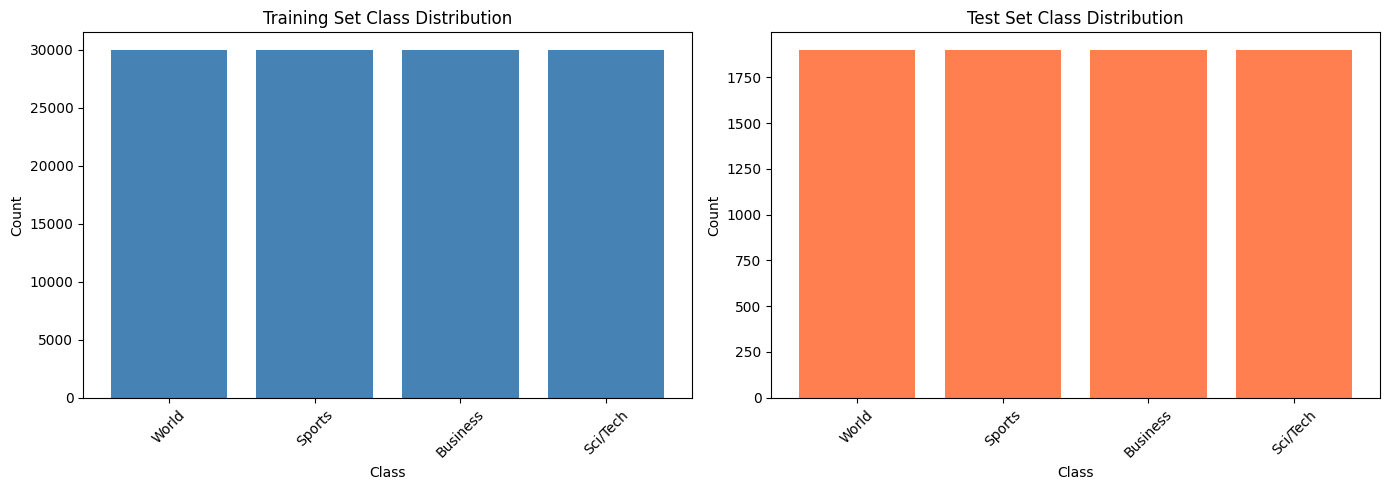


Class distribution statistics:
Training set:
Class Index
1    30000
2    30000
3    30000
4    30000
Name: count, dtype: int64

Test set:
Class Index
1    1900
2    1900
3    1900
4    1900
Name: count, dtype: int64


In [ ]:
# Map numeric class indices to readable class names
class_names = {1: 'World', 2: 'Sports', 3: 'Business', 4: 'Sci/Tech'}

# Create side-by-side bar plots for train and test class distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training set distribution
train_class_dist = train_df['Class Index'].value_counts().sort_index()
axes[0].bar([class_names[i] for i in train_class_dist.index], train_class_dist.values, color='steelblue')
axes[0].set_title('Training Set Class Distribution')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Test set distribution
test_class_dist = test_df['Class Index'].value_counts().sort_index()
axes[1].bar([class_names[i] for i in test_class_dist.index], test_class_dist.values, color='coral')
axes[1].set_title('Test Set Class Distribution')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ag_news_classification/results/class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# Print detailed statistics
print("\nClass distribution statistics:")
print("Training set:")
print(train_class_dist)
print("\nTest set:")
print(test_class_dist)

### 3.2 Text Length Analysis

Analyze the distribution of text lengths to understand:
- Average article length
- Variability in text length
- Whether length varies significantly across classes

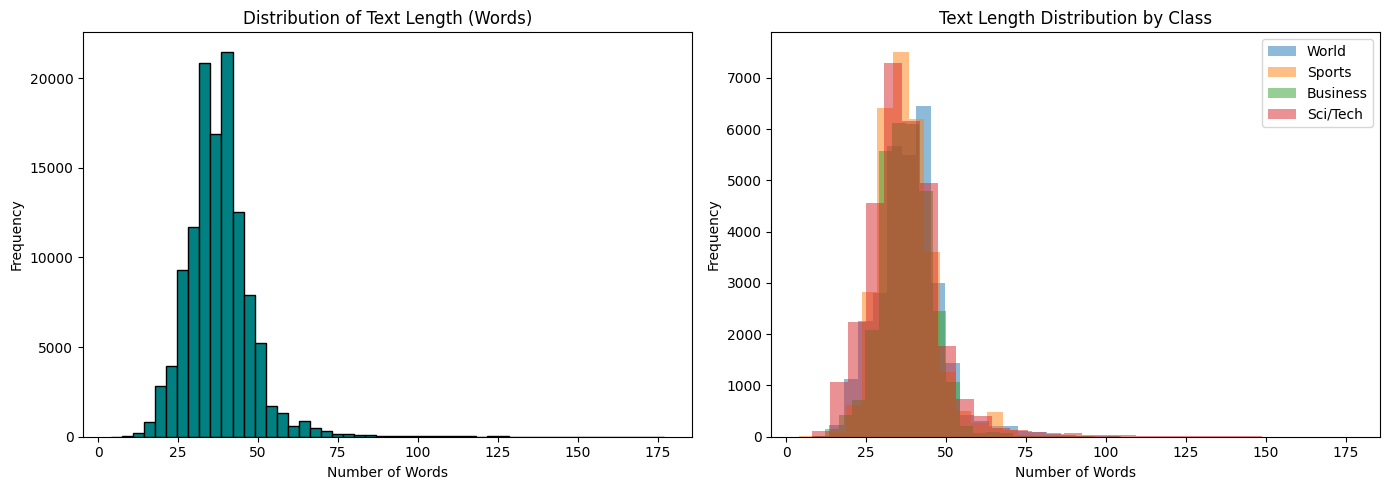


Text length statistics:
Mean: 37.84 words
Median: 37.00 words
Min: 4 words
Max: 177 words


In [ ]:
# Combine title and description to create full text
train_df['combined_text'] = train_df['Title'].fillna('') + ' ' + train_df['Description'].fillna('')
# Calculate text length in words
train_df['text_length'] = train_df['combined_text'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall text length distribution
axes[0].hist(train_df['text_length'], bins=50, color='teal', edgecolor='black')
axes[0].set_title('Distribution of Text Length (Words)')
axes[0].set_xlabel('Number of Words')
axes[0].set_ylabel('Frequency')

# Text length distribution by class
for class_idx in range(1, 5):
    class_data = train_df[train_df['Class Index'] == class_idx]['text_length']
    axes[1].hist(class_data, bins=30, alpha=0.5, label=class_names[class_idx])

axes[1].set_title('Text Length Distribution by Class')
axes[1].set_xlabel('Number of Words')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ag_news_classification/results/text_length_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# Summary statistics for text length
print(f"\nText length statistics:")
print(f"Mean: {train_df['text_length'].mean():.2f} words")
print(f"Median: {train_df['text_length'].median():.2f} words")
print(f"Min: {train_df['text_length'].min()} words")
print(f"Max: {train_df['text_length'].max()} words")

### 3.3 Word Frequency Analysis

Identify the most frequently occurring words in the corpus. This helps understand:
- Common terms across all classes
- Whether stopwords dominate
- Domain-specific vocabulary

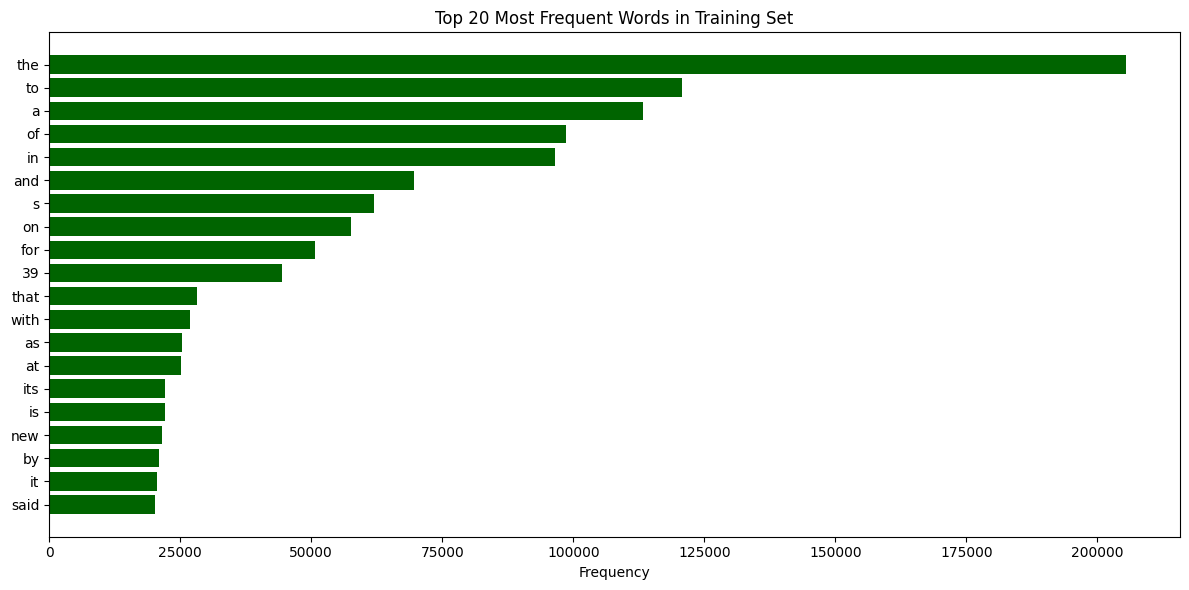


Total unique words: 65,036
Total words: 4,758,806


In [ ]:
from collections import Counter
import re

# Extract all words from the corpus
all_words = ' '.join(train_df['combined_text'].values).lower()
words = re.findall(r'\b\w+\b', all_words)
word_freq = Counter(words)
most_common = word_freq.most_common(20)

words_list, counts_list = zip(*most_common)

# Create horizontal bar chart for better readability
plt.figure(figsize=(12, 6))
plt.barh(range(len(words_list)), counts_list, color='darkgreen')
plt.yticks(range(len(words_list)), words_list)
plt.xlabel('Frequency')
plt.title('Top 20 Most Frequent Words in Training Set')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ag_news_classification/results/word_frequency.png', dpi=300, bbox_inches='tight')
plt.show()

# Print vocabulary statistics
print(f"\nTotal unique words: {len(word_freq):,}")
print(f"Total words: {len(words):,}")

### 3.4 Vocabulary Size by Class

Compare vocabulary richness across different news categories. Different domains may have varying lexical diversity.

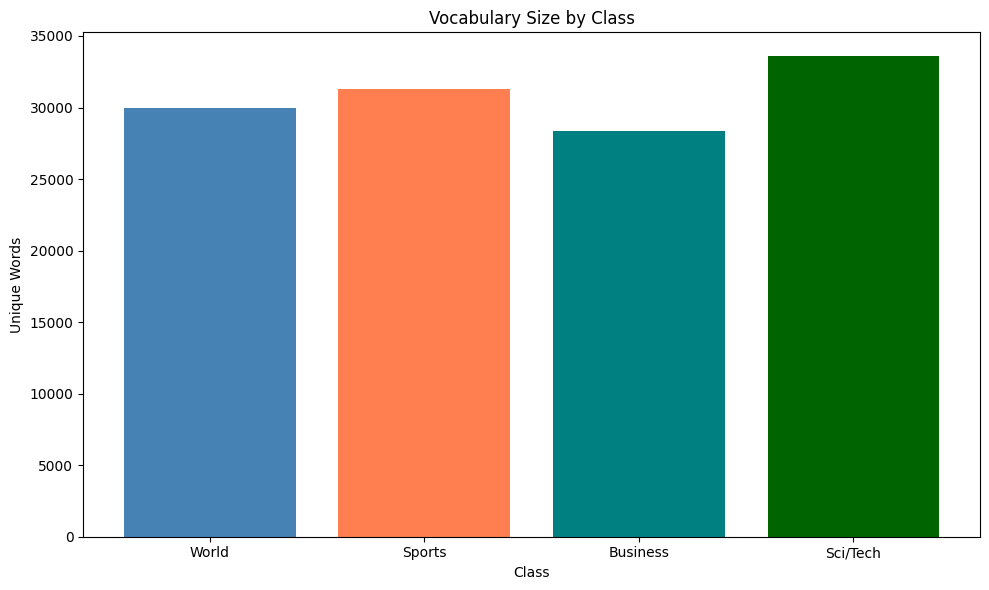

World: 29,985 unique words
Sports: 31,267 unique words
Business: 28,325 unique words
Sci/Tech: 33,576 unique words


In [ ]:
# Calculate unique vocabulary for each class
vocab_sizes = []
for class_idx in range(1, 5):
    class_text = ' '.join(train_df[train_df['Class Index'] == class_idx]['combined_text'].values).lower()
    class_words = re.findall(r'\b\w+\b', class_text)
    vocab_sizes.append(len(set(class_words)))

# Visualize vocabulary size comparison
plt.figure(figsize=(10, 6))
plt.bar([class_names[i] for i in range(1, 5)], vocab_sizes, color=['steelblue', 'coral', 'teal', 'darkgreen'])
plt.title('Vocabulary Size by Class')
plt.xlabel('Class')
plt.ylabel('Unique Words')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ag_news_classification/results/vocabulary_by_class.png', dpi=300, bbox_inches='tight')
plt.show()

# Print detailed vocabulary counts
for i, class_idx in enumerate(range(1, 5)):
    print(f"{class_names[class_idx]}: {vocab_sizes[i]:,} unique words")

## 4. Shared Preprocessing

This preprocessing pipeline is used consistently to ensure fair comparison across models.

**Preprocessing steps:**
1. **Text construction**: Combine Title and Description fields
2. **Text cleaning**: Lowercase conversion, URL removal, whitespace normalization
3. **Label encoding**: Convert class indices from 1-based to 0-based
4. **Train-validation split**: Stratified 80-20 split with fixed random seed

**Rationale**: Minimal preprocessing preserves linguistic information needed for both traditional and deep learning models.

In [ ]:
# Initialize preprocessor with fixed random state for reproducibility
preprocessor = SharedPreprocessor(random_state=42, val_size=0.2)

# Apply preprocessing to training and test datasets
train_processed = preprocessor.preprocess_dataset(train_df)
test_processed = preprocessor.preprocess_dataset(test_df)

# Verify preprocessing was applied correctly
verify_preprocessing(train_df, train_processed)

Preprocessing Verification
Original shape: (120000, 5)
Processed shape: (120000, 7)

Original columns: ['Class Index', 'Title', 'Description', 'combined_text', 'text_length']
Processed columns: ['Class Index', 'Title', 'Description', 'combined_text', 'text_length', 'text', 'label']

Label distribution:
label
0    30000
1    30000
2    30000
3    30000
Name: count, dtype: int64

Sample processed text (first 3):

Label 2:
wall st. bears claw back into the black (reuters) reuters - short-sellers, wall street's dwindling\band of ultra-cynics, are seeing green again....

Label 2:
carlyle looks toward commercial aerospace (reuters) reuters - private investment firm carlyle group,\which has a reputation for making well-timed and occasionally\controversial plays in the defense in...

Label 2:
oil and economy cloud stocks' outlook (reuters) reuters - soaring crude prices plus worries\about the economy and the outlook for earnings are expected to\hang over the stock market next week during t...


### 4.1 Create Train-Validation Split

Create a stratified train-validation split and save indices.

In [ ]:
# Extract features and labels
X = train_processed['text']
y = train_processed['label']

# Create stratified split and save indices for team consistency
X_train, X_val, y_train, y_val, train_idx, val_idx = preprocessor.create_train_val_split(
    X, y,
    save_indices=True,
    indices_dir='/content/drive/MyDrive/ag_news_classification/data'
)

# Prepare test set
X_test = test_processed['text']
y_test = test_processed['label']

# Display split statistics
print(f"\nTraining set size: {len(X_train)}")
print(f"Validation set size: {len(X_val)}")
print(f"Test set size: {len(X_test)}")
print(f"\nSplit indices saved for team consistency")


Training set size: 96000
Validation set size: 24000
Test set size: 7600

Split indices saved for team consistency


## 5. Hyperparameter Tuning

Systematic hyperparameter search for each embedding type using grid search with validation set evaluation.

**Strategy**: For each embedding, we explore different hyperparameter combinations and select the configuration that maximizes validation accuracy.

### 5.1 TF-IDF Hyperparameter Tuning

**Parameters explored:**
- max_features: [2000, 3000, 5000] - Vocabulary size
- C: [0.1, 1.0, 10.0] - Regularization strength
- ngram_range: [(1,1), (1,2)] - Unigrams only vs unigrams + bigrams

In [ ]:
# Initialize tuner and perform grid search
tfidf_tuner = HyperparameterTuner(embedding_type='tfidf', random_state=42)
best_tfidf_params = tfidf_tuner.tune_tfidf(X_train, y_train, X_val, y_val)

# Save tuning results for analysis
tfidf_results_df = pd.DataFrame(tfidf_tuner.results)
tfidf_results_df.to_csv('/content/drive/MyDrive/ag_news_classification/results/tfidf_tuning_results.csv', index=False)
print("\nTF-IDF tuning results saved")


Tuning hyperparameters for TF-IDF...
max_features=2000, C=0.1, ngram=(1, 1): 0.8865
max_features=2000, C=0.1, ngram=(1, 2): 0.8806
max_features=2000, C=1.0, ngram=(1, 1): 0.8925
max_features=2000, C=1.0, ngram=(1, 2): 0.8891
max_features=2000, C=10.0, ngram=(1, 1): 0.8899
max_features=2000, C=10.0, ngram=(1, 2): 0.8837
max_features=3000, C=0.1, ngram=(1, 1): 0.8934
max_features=3000, C=0.1, ngram=(1, 2): 0.8872
max_features=3000, C=1.0, ngram=(1, 1): 0.9014
max_features=3000, C=1.0, ngram=(1, 2): 0.8978
max_features=3000, C=10.0, ngram=(1, 1): 0.8969
max_features=3000, C=10.0, ngram=(1, 2): 0.8924
max_features=5000, C=0.1, ngram=(1, 1): 0.8994
max_features=5000, C=0.1, ngram=(1, 2): 0.8945
max_features=5000, C=1.0, ngram=(1, 1): 0.9103
max_features=5000, C=1.0, ngram=(1, 2): 0.9059
max_features=5000, C=10.0, ngram=(1, 1): 0.9029
max_features=5000, C=10.0, ngram=(1, 2): 0.8988

Best parameters: {'max_features': 5000, 'C': 1.0, 'ngram_range': (1, 1)}
Best validation accuracy: 0.9103

TF

### 5.2 Word2Vec Skip-gram Hyperparameter Tuning

**Parameters explored:**
- vector_size: [50, 100, 200] - Embedding dimension
- window: [3, 5, 7] - Context window size
- C: [0.1, 1.0, 10.0] - Logistic regression regularization

**Skip-gram**: Predicts context words given target word, better for rare words.

In [ ]:
# Tune Skip-gram Word2Vec embeddings
skipgram_tuner = HyperparameterTuner(embedding_type='word2vec_skipgram', random_state=42)
best_skipgram_params = skipgram_tuner.tune_word2vec(X_train, y_train, X_val, y_val, sg=1)

# Save results
skipgram_results_df = pd.DataFrame(skipgram_tuner.results)
skipgram_results_df.to_csv('/content/drive/MyDrive/ag_news_classification/results/skipgram_tuning_results.csv', index=False)
print("\nWord2Vec Skip-gram tuning results saved")


Tuning hyperparameters for Word2Vec (Skip-gram)...
vector_size=50, window=3, C=0.1: 0.8811
vector_size=50, window=3, C=1.0: 0.8804
vector_size=50, window=3, C=10.0: 0.8814
vector_size=50, window=5, C=0.1: 0.8878
vector_size=50, window=5, C=1.0: 0.8871
vector_size=50, window=5, C=10.0: 0.8875
vector_size=50, window=7, C=0.1: 0.8894
vector_size=50, window=7, C=1.0: 0.8905
vector_size=50, window=7, C=10.0: 0.8906
vector_size=100, window=3, C=0.1: 0.8877
vector_size=100, window=3, C=1.0: 0.8876
vector_size=100, window=3, C=10.0: 0.8876
vector_size=100, window=5, C=0.1: 0.8932
vector_size=100, window=5, C=1.0: 0.8940
vector_size=100, window=5, C=10.0: 0.8915
vector_size=100, window=7, C=0.1: 0.8963
vector_size=100, window=7, C=1.0: 0.8960
vector_size=100, window=7, C=10.0: 0.8960
vector_size=200, window=3, C=0.1: 0.8917
vector_size=200, window=3, C=1.0: 0.8924
vector_size=200, window=3, C=10.0: 0.8925
vector_size=200, window=5, C=0.1: 0.8967
vector_size=200, window=5, C=1.0: 0.8976
vector_

### 5.3 Word2Vec CBOW Hyperparameter Tuning

In [ ]:
# Tune CBOW Word2Vec embeddings
cbow_tuner = HyperparameterTuner(embedding_type='word2vec_cbow', random_state=42)
best_cbow_params = cbow_tuner.tune_word2vec(X_train, y_train, X_val, y_val, sg=0)

# Save results
cbow_results_df = pd.DataFrame(cbow_tuner.results)
cbow_results_df.to_csv('/content/drive/MyDrive/ag_news_classification/results/cbow_tuning_results.csv', index=False)
print("\nWord2Vec CBOW tuning results saved")


Tuning hyperparameters for Word2Vec (CBOW)...
vector_size=50, window=3, C=0.1: 0.8613
vector_size=50, window=3, C=1.0: 0.8595
vector_size=50, window=3, C=10.0: 0.8598
vector_size=50, window=5, C=0.1: 0.8639
vector_size=50, window=5, C=1.0: 0.8641
vector_size=50, window=5, C=10.0: 0.8658
vector_size=50, window=7, C=0.1: 0.8668
vector_size=50, window=7, C=1.0: 0.8664
vector_size=50, window=7, C=10.0: 0.8686
vector_size=100, window=3, C=0.1: 0.8708
vector_size=100, window=3, C=1.0: 0.8704
vector_size=100, window=3, C=10.0: 0.8685
vector_size=100, window=5, C=0.1: 0.8729
vector_size=100, window=5, C=1.0: 0.8721
vector_size=100, window=5, C=10.0: 0.8732
vector_size=100, window=7, C=0.1: 0.8744
vector_size=100, window=7, C=1.0: 0.8740
vector_size=100, window=7, C=10.0: 0.8731
vector_size=200, window=3, C=0.1: 0.8719
vector_size=200, window=3, C=1.0: 0.8754
vector_size=200, window=3, C=10.0: 0.8770
vector_size=200, window=5, C=0.1: 0.8769
vector_size=200, window=5, C=1.0: 0.8778
vector_size=

### 5.4 GloVe Hyperparameter Tuning

In [ ]:
# Tune GloVe-based classifier
glove_tuner = HyperparameterTuner(embedding_type='glove', random_state=42)
best_glove_params = glove_tuner.tune_glove(X_train, y_train, X_val, y_val)

# Save results
glove_results_df = pd.DataFrame(glove_tuner.results)
glove_results_df.to_csv('/content/drive/MyDrive/ag_news_classification/results/glove_tuning_results.csv', index=False)
print("\nGloVe tuning results saved")


Tuning hyperparameters for GloVe...
Loading GloVe embeddings...
[==================================================] 100.0% 128.1/128.1MB downloaded
C=0.1: 0.8854
C=1.0: 0.8863
C=10.0: 0.8866
C=100.0: 0.8864

Best parameters: {'C': 10.0}
Best validation accuracy: 0.8866

GloVe tuning results saved


## 6. Model Training with Best Parameters

### 6.1 Logistic Regression with TF-IDF

In [22]:
lr_tfidf = LogisticRegressionClassifier(
    embedding_type='tfidf',
    max_features=best_tfidf_params['max_features'],
    random_state=42
)

lr_tfidf.fit(X_train, y_train)

val_results_tfidf = lr_tfidf.evaluate(X_val, y_val)
test_results_tfidf = lr_tfidf.evaluate(X_test, y_test)

print(f"\nValidation Results - TF-IDF:")
print(f"Accuracy: {val_results_tfidf['accuracy']:.4f}")
print(f"Precision: {val_results_tfidf['precision']:.4f}")
print(f"Recall: {val_results_tfidf['recall']:.4f}")
print(f"F1-Score: {val_results_tfidf['f1_score']:.4f}")

print(f"\nTest Results - TF-IDF:")
print(f"Accuracy: {test_results_tfidf['accuracy']:.4f}")
print(f"Precision: {test_results_tfidf['precision']:.4f}")
print(f"Recall: {test_results_tfidf['recall']:.4f}")
print(f"F1-Score: {test_results_tfidf['f1_score']:.4f}")


Training Logistic Regression with tfidf...
Training completed for tfidf

Validation Results - TF-IDF:
Accuracy: 0.9059
Precision: 0.9056
Recall: 0.9059
F1-Score: 0.9057

Test Results - TF-IDF:
Accuracy: 0.8989
Precision: 0.8987
Recall: 0.8989
F1-Score: 0.8987


### 6.2 Logistic Regression with Word2Vec Skip-gram

In [23]:
lr_skipgram = LogisticRegressionClassifier(
    embedding_type='word2vec_skipgram',
    vector_size=best_skipgram_params['vector_size'],
    window=best_skipgram_params['window'],
    random_state=42
)

lr_skipgram.fit(X_train, y_train)

val_results_skipgram = lr_skipgram.evaluate(X_val, y_val)
test_results_skipgram = lr_skipgram.evaluate(X_test, y_test)

print(f"\nValidation Results - Word2Vec Skip-gram:")
print(f"Accuracy: {val_results_skipgram['accuracy']:.4f}")
print(f"Precision: {val_results_skipgram['precision']:.4f}")
print(f"Recall: {val_results_skipgram['recall']:.4f}")
print(f"F1-Score: {val_results_skipgram['f1_score']:.4f}")

print(f"\nTest Results - Word2Vec Skip-gram:")
print(f"Accuracy: {test_results_skipgram['accuracy']:.4f}")
print(f"Precision: {test_results_skipgram['precision']:.4f}")
print(f"Recall: {test_results_skipgram['recall']:.4f}")
print(f"F1-Score: {test_results_skipgram['f1_score']:.4f}")


Training Logistic Regression with word2vec_skipgram...
Training completed for word2vec_skipgram

Validation Results - Word2Vec Skip-gram:
Accuracy: 0.9012
Precision: 0.9010
Recall: 0.9012
F1-Score: 0.9010

Test Results - Word2Vec Skip-gram:
Accuracy: 0.8945
Precision: 0.8942
Recall: 0.8945
F1-Score: 0.8942


### 6.3 Logistic Regression with Word2Vec CBOW

In [24]:
lr_cbow = LogisticRegressionClassifier(
    embedding_type='word2vec_cbow',
    vector_size=best_cbow_params['vector_size'],
    window=best_cbow_params['window'],
    random_state=42
)

lr_cbow.fit(X_train, y_train)

val_results_cbow = lr_cbow.evaluate(X_val, y_val)
test_results_cbow = lr_cbow.evaluate(X_test, y_test)

print(f"\nValidation Results - Word2Vec CBOW:")
print(f"Accuracy: {val_results_cbow['accuracy']:.4f}")
print(f"Precision: {val_results_cbow['precision']:.4f}")
print(f"Recall: {val_results_cbow['recall']:.4f}")
print(f"F1-Score: {val_results_cbow['f1_score']:.4f}")

print(f"\nTest Results - Word2Vec CBOW:")
print(f"Accuracy: {test_results_cbow['accuracy']:.4f}")
print(f"Precision: {test_results_cbow['precision']:.4f}")
print(f"Recall: {test_results_cbow['recall']:.4f}")
print(f"F1-Score: {test_results_cbow['f1_score']:.4f}")


Training Logistic Regression with word2vec_cbow...
Training completed for word2vec_cbow

Validation Results - Word2Vec CBOW:
Accuracy: 0.8801
Precision: 0.8797
Recall: 0.8801
F1-Score: 0.8798

Test Results - Word2Vec CBOW:
Accuracy: 0.8693
Precision: 0.8688
Recall: 0.8693
F1-Score: 0.8690


### 6.4 Logistic Regression with GloVe

In [25]:
lr_glove = LogisticRegressionClassifier(
    embedding_type='glove',
    random_state=42
)

lr_glove.fit(X_train, y_train)

val_results_glove = lr_glove.evaluate(X_val, y_val)
test_results_glove = lr_glove.evaluate(X_test, y_test)

print(f"\nValidation Results - GloVe:")
print(f"Accuracy: {val_results_glove['accuracy']:.4f}")
print(f"Precision: {val_results_glove['precision']:.4f}")
print(f"Recall: {val_results_glove['recall']:.4f}")
print(f"F1-Score: {val_results_glove['f1_score']:.4f}")

print(f"\nTest Results - GloVe:")
print(f"Accuracy: {test_results_glove['accuracy']:.4f}")
print(f"Precision: {test_results_glove['precision']:.4f}")
print(f"Recall: {test_results_glove['recall']:.4f}")
print(f"F1-Score: {test_results_glove['f1_score']:.4f}")


Training Logistic Regression with glove...
Loading pre-trained GloVe embeddings (this may take a few minutes)...
GloVe embeddings loaded successfully
Training completed for glove

Validation Results - GloVe:
Accuracy: 0.8863
Precision: 0.8860
Recall: 0.8863
F1-Score: 0.8861

Test Results - GloVe:
Accuracy: 0.8832
Precision: 0.8829
Recall: 0.8832
F1-Score: 0.8830


## 7. Results Comparison

In [26]:
results_comparison = pd.DataFrame({
    'Embedding': ['TF-IDF', 'Word2Vec Skip-gram', 'Word2Vec CBOW', 'GloVe'],
    'Val_Accuracy': [
        val_results_tfidf['accuracy'],
        val_results_skipgram['accuracy'],
        val_results_cbow['accuracy'],
        val_results_glove['accuracy']
    ],
    'Val_Precision': [
        val_results_tfidf['precision'],
        val_results_skipgram['precision'],
        val_results_cbow['precision'],
        val_results_glove['precision']
    ],
    'Val_Recall': [
        val_results_tfidf['recall'],
        val_results_skipgram['recall'],
        val_results_cbow['recall'],
        val_results_glove['recall']
    ],
    'Val_F1': [
        val_results_tfidf['f1_score'],
        val_results_skipgram['f1_score'],
        val_results_cbow['f1_score'],
        val_results_glove['f1_score']
    ],
    'Test_Accuracy': [
        test_results_tfidf['accuracy'],
        test_results_skipgram['accuracy'],
        test_results_cbow['accuracy'],
        test_results_glove['accuracy']
    ],
    'Test_Precision': [
        test_results_tfidf['precision'],
        test_results_skipgram['precision'],
        test_results_cbow['precision'],
        test_results_glove['precision']
    ],
    'Test_Recall': [
        test_results_tfidf['recall'],
        test_results_skipgram['recall'],
        test_results_cbow['recall'],
        test_results_glove['recall']
    ],
    'Test_F1': [
        test_results_tfidf['f1_score'],
        test_results_skipgram['f1_score'],
        test_results_cbow['f1_score'],
        test_results_glove['f1_score']
    ]
})

results_comparison.to_csv('/content/drive/MyDrive/ag_news_classification/results/logistic_regression_results.csv', index=False)
print("\nLogistic Regression Results Comparison:")
print(results_comparison.to_string(index=False))


Logistic Regression Results Comparison:
         Embedding  Val_Accuracy  Val_Precision  Val_Recall   Val_F1  Test_Accuracy  Test_Precision  Test_Recall  Test_F1
            TF-IDF      0.905875       0.905626    0.905875 0.905664       0.898947        0.898700     0.898947 0.898735
Word2Vec Skip-gram      0.901208       0.900975    0.901208 0.901001       0.894474        0.894159     0.894474 0.894246
     Word2Vec CBOW      0.880083       0.879693    0.880083 0.879802       0.869342        0.868763     0.869342 0.868962
             GloVe      0.886333       0.886020    0.886333 0.886143       0.883158        0.882891     0.883158 0.883003


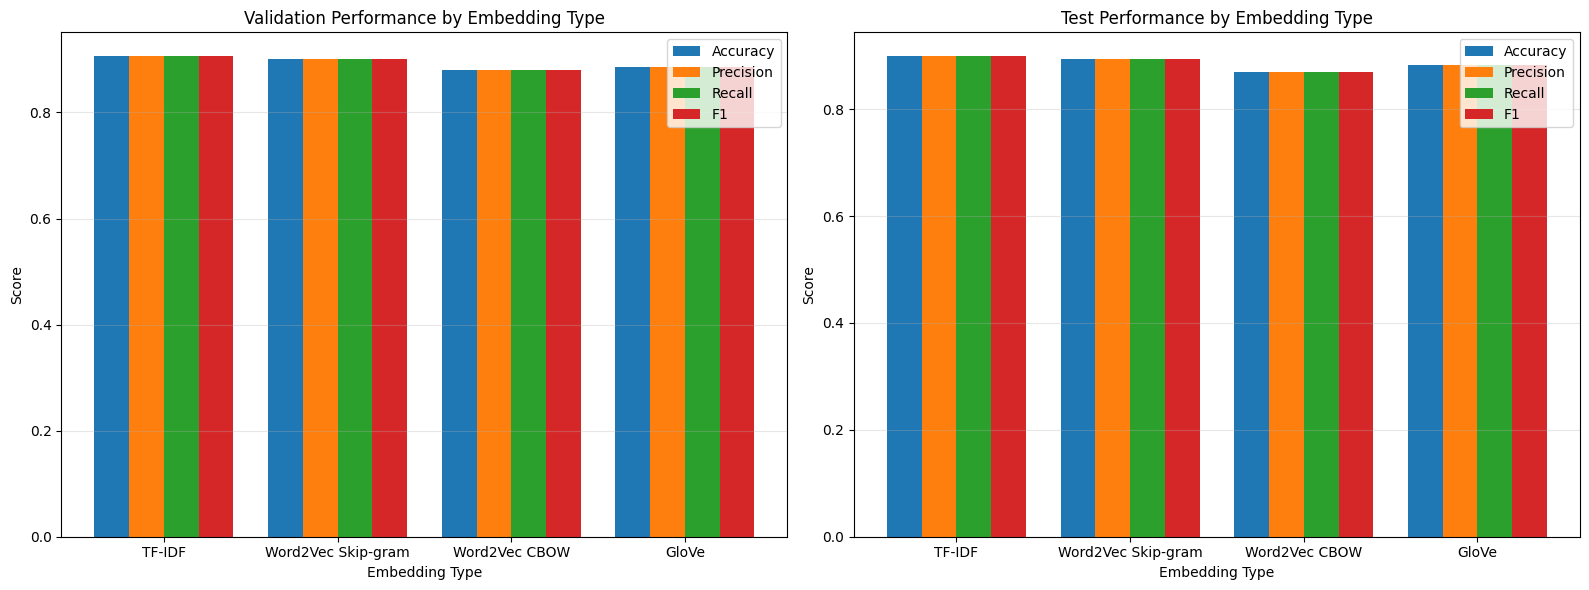

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

metrics = ['Val_Accuracy', 'Val_Precision', 'Val_Recall', 'Val_F1']
x_pos = np.arange(len(results_comparison))
width = 0.2

for i, metric in enumerate(metrics):
    axes[0].bar(x_pos + i*width, results_comparison[metric], width, label=metric.replace('Val_', ''))

axes[0].set_xlabel('Embedding Type')
axes[0].set_ylabel('Score')
axes[0].set_title('Validation Performance by Embedding Type')
axes[0].set_xticks(x_pos + width * 1.5)
axes[0].set_xticklabels(results_comparison['Embedding'])
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

test_metrics = ['Test_Accuracy', 'Test_Precision', 'Test_Recall', 'Test_F1']
for i, metric in enumerate(test_metrics):
    axes[1].bar(x_pos + i*width, results_comparison[metric], width, label=metric.replace('Test_', ''))

axes[1].set_xlabel('Embedding Type')
axes[1].set_ylabel('Score')
axes[1].set_title('Test Performance by Embedding Type')
axes[1].set_xticks(x_pos + width * 1.5)
axes[1].set_xticklabels(results_comparison['Embedding'])
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ag_news_classification/results/lr_performance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. Confusion Matrices

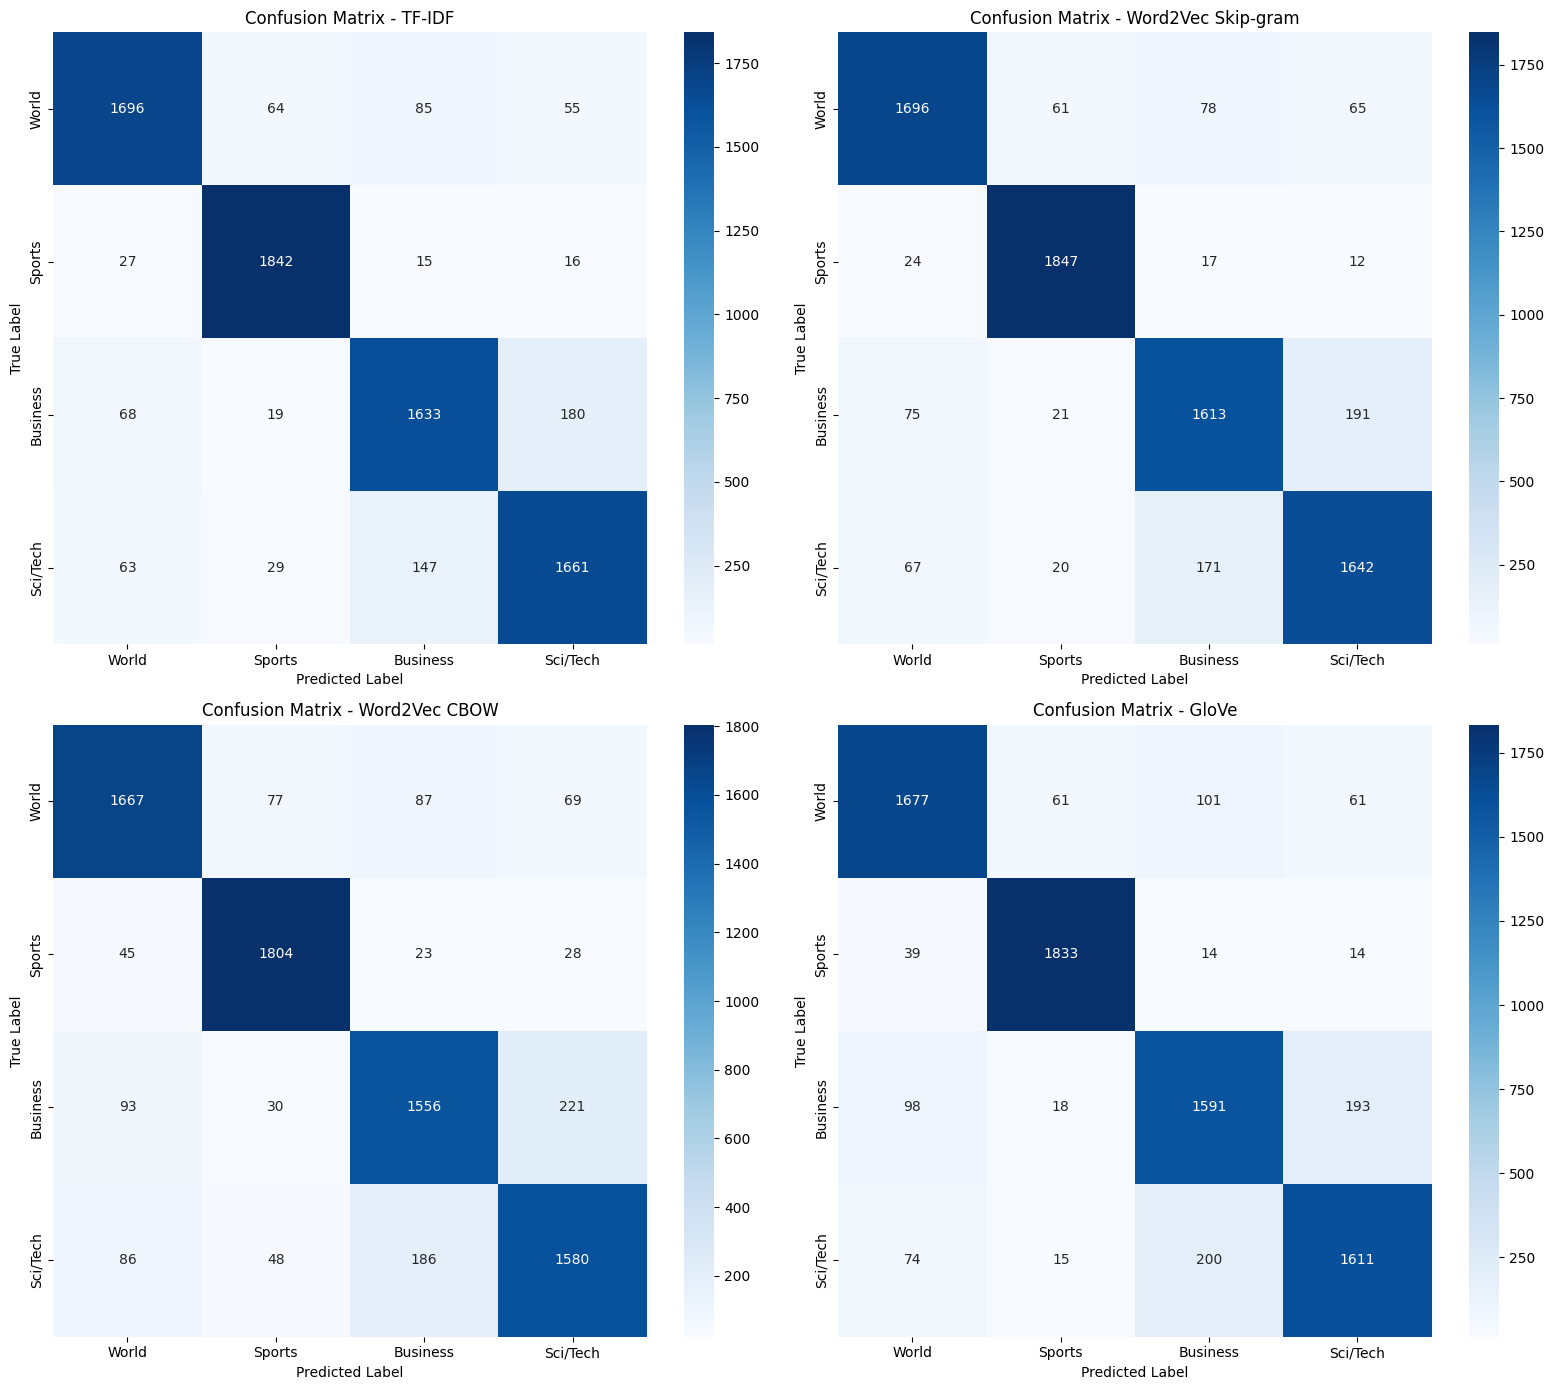

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

class_names_list = ['World', 'Sports', 'Business', 'Sci/Tech']

cms = [
    (test_results_tfidf['confusion_matrix'], 'TF-IDF'),
    (test_results_skipgram['confusion_matrix'], 'Word2Vec Skip-gram'),
    (test_results_cbow['confusion_matrix'], 'Word2Vec CBOW'),
    (test_results_glove['confusion_matrix'], 'GloVe')
]

for idx, (cm, title) in enumerate(cms):
    ax = axes[idx // 2, idx % 2]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=class_names_list, yticklabels=class_names_list)
    ax.set_title(f'Confusion Matrix - {title}')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ag_news_classification/results/lr_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

## 9. Per-Class Performance Analysis

In [29]:
per_class_results = []

embeddings = ['TF-IDF', 'Word2Vec Skip-gram', 'Word2Vec CBOW', 'GloVe']
results_list = [test_results_tfidf, test_results_skipgram, test_results_cbow, test_results_glove]

for emb, res in zip(embeddings, results_list):
    for i, class_name in enumerate(class_names_list):
        per_class_results.append({
            'Embedding': emb,
            'Class': class_name,
            'Precision': res['precision_per_class'][i],
            'Recall': res['recall_per_class'][i],
            'F1-Score': res['f1_per_class'][i]
        })

per_class_df = pd.DataFrame(per_class_results)
per_class_df.to_csv('/content/drive/MyDrive/ag_news_classification/results/lr_per_class_results.csv', index=False)

print("\nPer-Class Performance:")
print(per_class_df.to_string(index=False))


Per-Class Performance:
         Embedding    Class  Precision   Recall  F1-Score
            TF-IDF    World   0.914779 0.892632  0.903570
            TF-IDF   Sports   0.942682 0.969474  0.955890
            TF-IDF Business   0.868617 0.859474  0.864021
            TF-IDF Sci/Tech   0.868724 0.874211  0.871459
Word2Vec Skip-gram    World   0.910849 0.892632  0.901648
Word2Vec Skip-gram   Sports   0.947665 0.972105  0.959730
Word2Vec Skip-gram Business   0.858435 0.848947  0.853665
Word2Vec Skip-gram Sci/Tech   0.859686 0.864211  0.861942
     Word2Vec CBOW    World   0.881544 0.877368  0.879451
     Word2Vec CBOW   Sports   0.920878 0.949474  0.934957
     Word2Vec CBOW Business   0.840173 0.818947  0.829424
     Word2Vec CBOW Sci/Tech   0.832455 0.831579  0.832017
             GloVe    World   0.888242 0.882632  0.885428
             GloVe   Sports   0.951220 0.964737  0.957930
             GloVe Business   0.834732 0.837368  0.836048
             GloVe Sci/Tech   0.857371 0.847895 

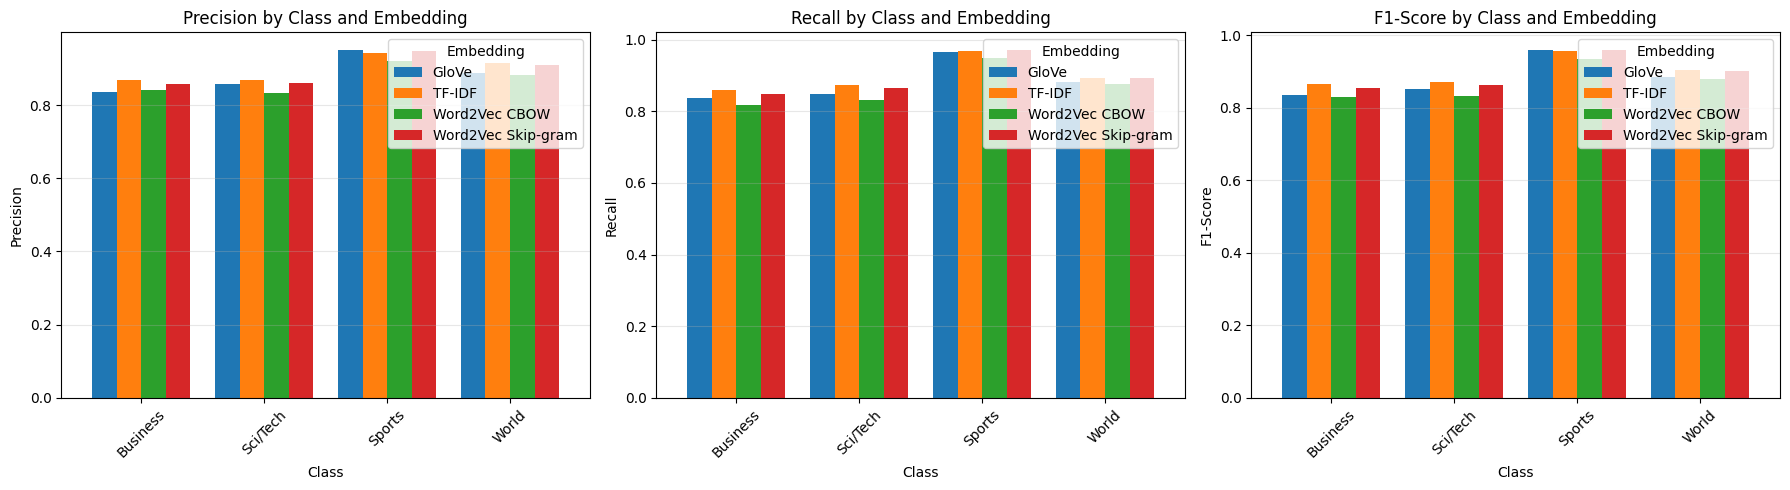

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics_to_plot = ['Precision', 'Recall', 'F1-Score']

for idx, metric in enumerate(metrics_to_plot):
    pivot_data = per_class_df.pivot(index='Class', columns='Embedding', values=metric)
    pivot_data.plot(kind='bar', ax=axes[idx], width=0.8)
    axes[idx].set_title(f'{metric} by Class and Embedding')
    axes[idx].set_xlabel('Class')
    axes[idx].set_ylabel(metric)
    axes[idx].legend(title='Embedding')
    axes[idx].grid(axis='y', alpha=0.3)
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ag_news_classification/results/lr_per_class_performance.png', dpi=300, bbox_inches='tight')
plt.show()

## 10. Classification Reports

In [31]:
print("TF-IDF Classification Report:")
print(classification_report(y_test, test_results_tfidf['predictions'], target_names=class_names_list))
print("\n" + "="*80 + "\n")

print("Word2Vec Skip-gram Classification Report:")
print(classification_report(y_test, test_results_skipgram['predictions'], target_names=class_names_list))
print("\n" + "="*80 + "\n")

print("Word2Vec CBOW Classification Report:")
print(classification_report(y_test, test_results_cbow['predictions'], target_names=class_names_list))
print("\n" + "="*80 + "\n")

print("GloVe Classification Report:")
print(classification_report(y_test, test_results_glove['predictions'], target_names=class_names_list))

TF-IDF Classification Report:
              precision    recall  f1-score   support

       World       0.91      0.89      0.90      1900
      Sports       0.94      0.97      0.96      1900
    Business       0.87      0.86      0.86      1900
    Sci/Tech       0.87      0.87      0.87      1900

    accuracy                           0.90      7600
   macro avg       0.90      0.90      0.90      7600
weighted avg       0.90      0.90      0.90      7600



Word2Vec Skip-gram Classification Report:
              precision    recall  f1-score   support

       World       0.91      0.89      0.90      1900
      Sports       0.95      0.97      0.96      1900
    Business       0.86      0.85      0.85      1900
    Sci/Tech       0.86      0.86      0.86      1900

    accuracy                           0.89      7600
   macro avg       0.89      0.89      0.89      7600
weighted avg       0.89      0.89      0.89      7600



Word2Vec CBOW Classification Report:
              pre

## 11. Key Findings Summary

This section summarizes the experimental findings for Logistic Regression across different embeddings.

In [32]:
best_embedding = results_comparison.loc[results_comparison['Test_Accuracy'].idxmax(), 'Embedding']
best_accuracy = results_comparison['Test_Accuracy'].max()

print("\nKey Findings:")
print("="*80)
print(f"Best performing embedding: {best_embedding}")
print(f"Best test accuracy: {best_accuracy:.4f}")
print("\nPerformance ranking (by test accuracy):")
ranked = results_comparison.sort_values('Test_Accuracy', ascending=False)
for idx, row in ranked.iterrows():
    print(f"{idx+1}. {row['Embedding']}: {row['Test_Accuracy']:.4f}")

print("\nObservations:")
if best_embedding == 'TF-IDF':
    print("- TF-IDF performs best, likely due to its ability to capture term importance")
    print("- Sparse representations work well with Logistic Regression for this dataset")
else:
    print(f"- {best_embedding} outperforms TF-IDF, suggesting semantic embeddings are beneficial")
    print("- Dense representations capture better contextual information for this task")

print("="*80)


Key Findings:
Best performing embedding: TF-IDF
Best test accuracy: 0.8989

Performance ranking (by test accuracy):
1. TF-IDF: 0.8989
2. Word2Vec Skip-gram: 0.8945
4. GloVe: 0.8832
3. Word2Vec CBOW: 0.8693

Observations:
- TF-IDF performs best, likely due to its ability to capture term importance
- Sparse representations work well with Logistic Regression for this dataset


## 12. Save Models

In [33]:
import pickle

models = {
    'tfidf': lr_tfidf,
    'skipgram': lr_skipgram,
    'cbow': lr_cbow,
    'glove': lr_glove
}

for name, model in models.items():
    with open(f'/content/drive/MyDrive/ag_news_classification/models/lr_{name}.pkl', 'wb') as f:
        pickle.dump(model, f)

print("All models saved successfully")

All models saved successfully
